# BNN Regression on Sinusoid using ```bayesian-torch```

We fit a deterministic MAP regressor on a noisy sinusoid (`x ∈ [0, 8]`) and turn it into a
variational Bayesian neural network with `bayesian-torch`. We compare variants over **layer type**
(Flipout / Reparameterization) and initialisation (from scratch vs MOPED warm-start from the
MAP), and inspect the predictive uncertainty, especially in the extrapolation (OOD) region.

In [23]:
from pathlib import Path
import sys
import os
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from shared import checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything, regression_uncertainty_stats, regression_metrics
from shared.helper.dataloaders import get_sinusoid_example

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 711
seed_everything(SEED)
sigma_noise = 0.3            # true data-generation noise (aleatoric)
num_mc_samples = 100         # MC samples for inference

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
checkpoint_dir = str(ROOT / "results" / "checkpoints" / "sinusoid_bayesian_1seed")
os.makedirs(checkpoint_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

Device: cuda


In [24]:
# Data + validation split + MAP
X_train, y_train, train_loader, X_test = get_sinusoid_example(n_data=150, sigma_noise=sigma_noise, batch_size=150)
X_train_np = X_train.flatten().numpy()
y_train_np = y_train.flatten().numpy()
x_grid = X_test.flatten().numpy()

# Held-out validation set (for early stopping) — same construction as the Laplace notebook
seed_everything(SEED + 1)
X_val = (torch.rand(50) * 8).unsqueeze(-1)
y_val = torch.sin(X_val) + sigma_noise * torch.randn_like(X_val)
y_val_np = y_val.flatten().numpy()

# Held-out test sets WITH targets, for scored metrics (NLL / RMSE / calibration)
seed_everything(SEED + 2)
X_test_id  = (torch.rand(100) * 8).unsqueeze(-1)                                 # in-distribution: x in [0, 8]
X_test_ood = torch.cat([torch.rand(60) * 5 - 5, torch.rand(60) * 5 + 8]).unsqueeze(-1)  # extrapolation: [-5,0] U [8,13]
y_test_id  = torch.sin(X_test_id)  + sigma_noise * torch.randn_like(X_test_id)
y_test_ood = torch.sin(X_test_ood) + sigma_noise * torch.randn_like(X_test_ood)
y_test_id_np  = y_test_id.flatten().numpy()
y_test_ood_np = y_test_ood.flatten().numpy()

# Visualization helper (identical to the Laplace notebook)
TRAIN_LO, TRAIN_HI = 0.0, 8.0   # training x-range; outside this is OOD/extrapolation
def plot_prediction(x_grid, f_mu, epistemic_std, aleatoric_std, title, ax):
    epi = np.asarray(epistemic_std).ravel()
    ale = float(aleatoric_std)
    total = np.sqrt(epi ** 2 + ale ** 2)
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.scatter(X_train_np, y_train_np, c="tab:blue", s=12, alpha=0.5, zorder=3, label="Train")
    ax.plot(x_grid, f_mu, color="tab:orange", lw=2, label="Predictive mean")
    ax.fill_between(x_grid, f_mu - 2*total, f_mu + 2*total, color="tab:orange", alpha=0.20, label="±2σ total")
    ax.fill_between(x_grid, f_mu - 2*epi, f_mu + 2*epi, color="tab:purple", alpha=0.30, label="±2σ epistemic")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)

def get_model():
    seed_everything(SEED)
    return torch.nn.Sequential(torch.nn.Linear(1, 50), torch.nn.Tanh(), torch.nn.Linear(50, 1))

# Train / load the shared MAP regressor (same checkpoint the Laplace notebook uses)
map_ckpt = str(ROOT / "results" / "checkpoints" / f"sinusoid_map_seed{SEED}.pt")
map_model = get_model()
criterion = nn.MSELoss()
if checkpoint_exists(map_ckpt):
    map_model.load_state_dict(load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
    print("Loaded MAP checkpoint")
else:
    opt = optim.Adam(map_model.parameters(), lr=1e-2)
    fit_start = time.time()
    for epoch in range(1000):
        for xb, yb in train_loader:
            opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
    save_checkpoint({"model_state_dict": map_model.state_dict(), "fit_time": time.time() - fit_start}, map_ckpt)
    print(f"Trained MAP ({time.time() - fit_start:.1f}s)")
map_model.eval()

# Parameter doubling: deterministic -> variational BNN (mean + variance per weight)
det_params = sum(p.numel() for p in map_model.parameters())
_probe = get_model()
dnn_to_bnn(_probe, {"prior_mu": 0.0, "prior_sigma": 1.0, "posterior_mu_init": 0.0,
                    "posterior_rho_init": -3.0, "type": "Reparameterization",
                    "moped_enable": False, "moped_delta": 0.5})
bnn_params = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
print(f"Deterministic params: {det_params:,}  ->  BNN params: {bnn_params:,}  ({bnn_params / det_params:.1f}x)")

def bnn_predict(net, X, n_samples=num_mc_samples):
    """MC sampling -> (mean, epistemic_std) numpy arrays on grid X."""
    net.eval()
    with torch.no_grad():
        preds = torch.stack([net(X) for _ in range(n_samples)])   # (S, N, 1)
    return preds.mean(0).squeeze().cpu().numpy(), preds.std(0).squeeze().cpu().numpy()

variant_results = {}

Loaded MAP checkpoint
Deterministic params: 151  ->  BNN params: 302  (2.0x)


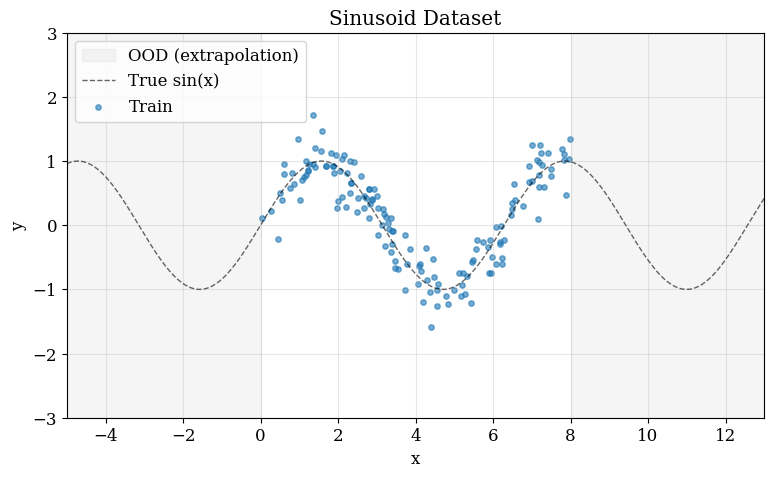

In [25]:
# Dataset visualization
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=15, alpha=0.6, label="Train")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Sinusoid Dataset")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

In [26]:
def build_bnn(model_type, moped, moped_delta=0.5):
    net = get_model()
    if moped:
        net.load_state_dict(map_model.state_dict())   # warm start from the MAP
    dnn_to_bnn(net, {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": model_type, "moped_enable": moped, "moped_delta": moped_delta,
    })
    return net


def fit_or_load_variant(spec):
    vname = spec["variant_name"]
    ckpt = os.path.join(checkpoint_dir, f"sinusoid_{vname}_seed{SEED}.pt")
    net = build_bnn(spec["model_type"], spec["moped"])

    if checkpoint_exists(ckpt):
        payload = load_checkpoint(ckpt, map_location="cpu")
        if isinstance(payload, dict) and "model_state_dict" in payload:
            net.load_state_dict(payload["model_state_dict"])
            return net, payload.get("metrics", {}), True

    optimizer = optim.Adam(net.parameters(), lr=1e-3)
    num_samples = len(X_train)
    max_epochs = spec["epochs"]; patience = 75
    best_val, best_state, wait, ran = float("inf"), None, 0, 0

    fit_start = time.time()
    for epoch in range(max_epochs):
        net.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(net(xb), yb) + get_kl_loss(net) / num_samples   # ELBO (MSE + KL)
            loss.backward(); optimizer.step()
        ran = epoch + 1
        # early stopping on validation MSE (MC-mean prediction)
        f_mu_val, _ = bnn_predict(net, X_val, n_samples=20)
        val_mse = float(np.mean((f_mu_val - y_val_np) ** 2))
        if val_mse < best_val - 1e-5:
            best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        net.load_state_dict(best_state)
    fit_time = time.time() - fit_start

    metrics = {
        "Model_Type": spec["model_type"],
        "Init": "MOPED" if spec["moped"] else "scratch",
        "Epochs": ran,
        "Best_Val_MSE": best_val,
        "Fit_Time (s)": fit_time,
    }
    save_checkpoint({"model_state_dict": net.state_dict(), "metrics": metrics}, ckpt)
    return net, metrics, False


# Variant grid: layer Type x Init = 4 variants
variant_specs = []
for model_type, short in [("Flipout", "Flipout"), ("Reparameterization", "BBB")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        variant_specs.append({
            "variant_name": f"{short.lower()}_{init}",
            "model_type": model_type,
            "moped": moped,
            "epochs": 400 if moped else 1000,   # MOPED warm-started -> fewer epochs (early stopping caps both)
            "plot_title": f"{short} / {init}",
        })
variant_results = {}
print(f"Configured {len(variant_specs)} BNN regression variants.")

Configured 4 BNN regression variants.


In [27]:
# Run all variants -> build variant_eval_df
variant_eval_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    print(f"  Training/loading: {vname}")
    net, v_metrics, from_cache = fit_or_load_variant(spec)
    v_metrics = dict(v_metrics)
    f_mu, epi_std = bnn_predict(net, X_test)                  # grid (for figures)
    mu_id, epi_id = bnn_predict(net, X_test_id)               # held-out ID test (for scored metrics)
    total_id = np.sqrt(epi_id ** 2 + sigma_noise ** 2)
    v_metrics.update(regression_uncertainty_stats(epi_id, sigma_noise))
    v_metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    variant_results[vname] = {"model": net, "f_mu": f_mu, "epi_std": epi_std, "metrics": v_metrics}
    variant_eval_rows.append(v_metrics)

variant_eval_df = pd.DataFrame(variant_eval_rows, index=[s["plot_title"] for s in variant_specs])
variant_eval_df.index.name = "Variant"
print(f"\nEvaluated {len(variant_eval_rows)} variants.")

  Training/loading: flipout_scratch


  Training/loading: flipout_moped
  Training/loading: bbb_scratch
  Training/loading: bbb_moped

Evaluated 4 variants.


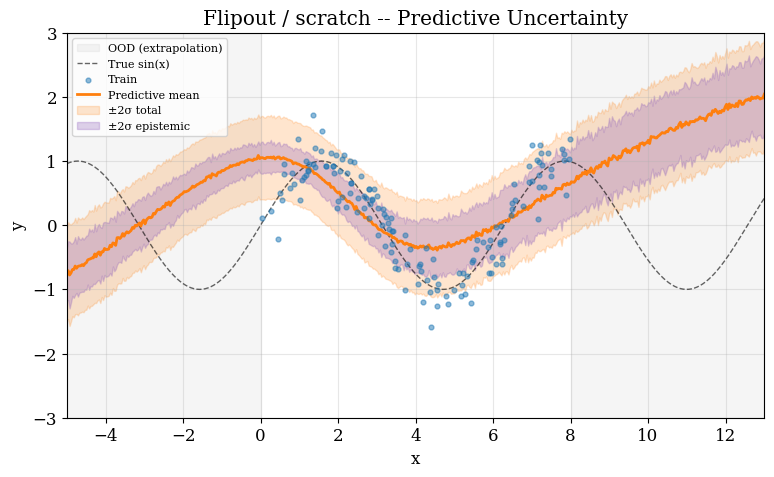

  Saved figure for: flipout_scratch


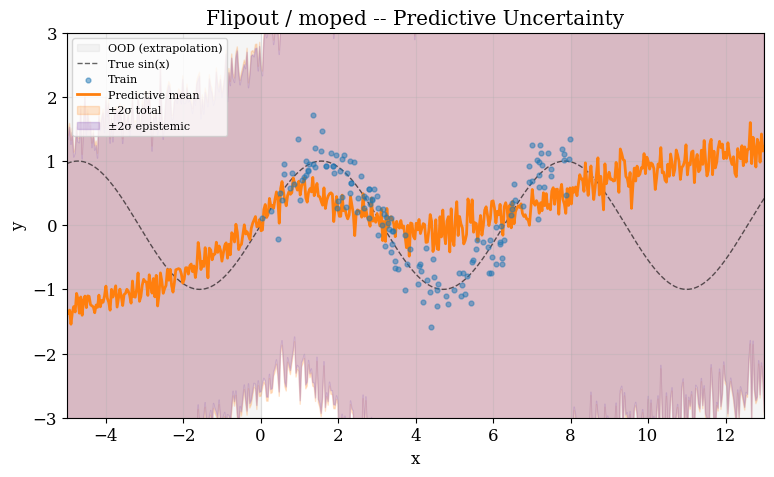

  Saved figure for: flipout_moped


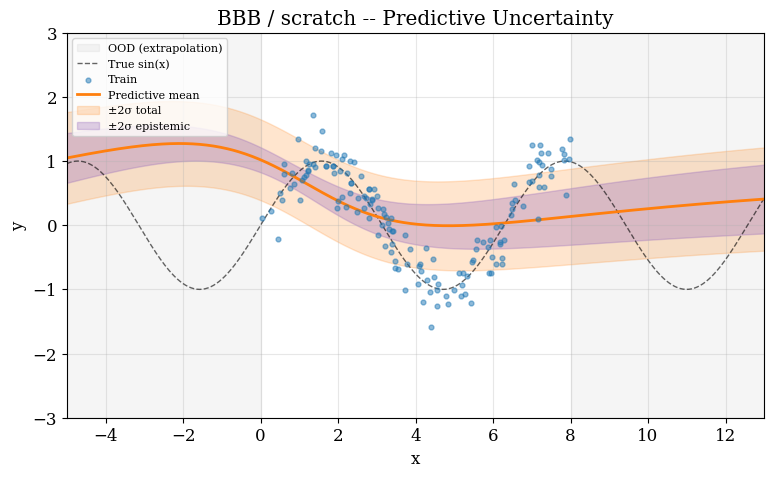

  Saved figure for: bbb_scratch


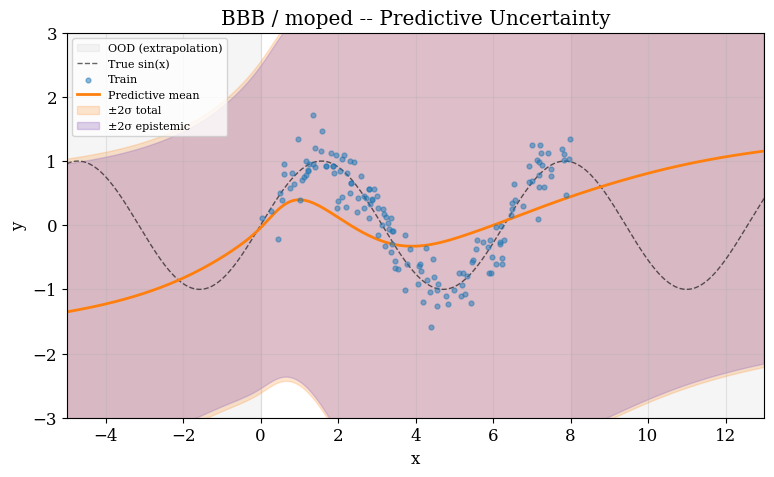

  Saved figure for: bbb_moped

Done: 4 figures written to ../figures


In [28]:
# Per-variant regression figures (mean + epistemic/total bands; OOD region shaded)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    res = variant_results[vname]
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, res["f_mu"], res["epi_std"], sigma_noise, f"{title} -- Predictive Uncertainty", ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_prediction.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved figure for: {vname}")
print(f"\nDone: {len(variant_specs)} figures written to {FIGURES_DIR}")

In [29]:
# Final metrics table (uncertainty stats)
variant_table = variant_eval_df.copy()
variant_table.index.name = "Model Type"
preferred_cols = [
    "Model_Type", "Init", "Epochs", "Best_Val_MSE", "Fit_Time (s)",
    "RMSE", "MAE", "NLL", "Calibration_MAE", "Calibration_MSE", "Calibration_Corr", "Max_Calibration_Gap",
    "Coverage_68", "Coverage_95",
    "Mean_Epistemic_Std", "Mean_Aleatoric_Std", "Mean_Total_Std",
]
existing = [c for c in preferred_cols if c in variant_table.columns]
variant_table = variant_table[existing + [c for c in variant_table.columns if c not in existing]]

disp = variant_table.copy()
for c in disp.columns:
    if pd.api.types.is_float_dtype(disp[c]):
        disp[c] = disp[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
    elif pd.api.types.is_integer_dtype(disp[c]):
        disp[c] = disp[c].map(lambda x: str(x) if pd.notna(x) else "-")
print("Sinusoid Bayesian-Torch -- Variant-Level Uncertainty Benchmarks")
display(disp)

os.makedirs("results/metrics", exist_ok=True)
variant_table.to_csv("results/metrics/sinusoid_bayesian_variant_metrics.csv")
print("\nSaved metrics to results/metrics/sinusoid_bayesian_variant_metrics.csv")

Sinusoid Bayesian-Torch -- Variant-Level Uncertainty Benchmarks


,Model_Type,Init,Epochs,Best_Val_MSE,Fit_Time (s),RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Calibration_Corr,Max_Calibration_Gap,Coverage_68,Coverage_95,Mean_Epistemic_Std,Mean_Aleatoric_Std,Mean_Total_Std
Model Type,,,,,,,,,,,,,,,,,
Flipout / scratch,Flipout,scratch,1000,0.1756,126.4589,0.4532,0.3921,0.6923,0.1525,0.0298,0.9590,0.2611,0.4400,0.9300,0.1903,0.3000,0.3579
Flipout / moped,Flipout,MOPED,134,0.2383,16.5469,0.5379,0.4362,1.5260,0.3290,0.1313,0.8376,0.5484,1.0000,1.0000,1.7499,0.3000,1.7760
BBB / scratch,Reparameterization,scratch,1000,0.2691,125.3343,0.5897,0.5086,1.2711,0.2475,0.0737,0.9521,0.3805,0.3000,0.7000,0.1645,0.3000,0.3445
BBB / moped,Reparameterization,MOPED,197,0.1479,34.1968,0.5799,0.4748,1.5657,0.3165,0.1228,0.8458,0.5211,1.0000,1.0000,1.8040,0.3000,1.8290



Saved metrics to results/metrics/sinusoid_bayesian_variant_metrics.csv


## In-Distribution vs OOD (extrapolation) Test

The training data lives on `x ∈ [0, 8]`; everything outside is out-of-distribution. A well-behaved
Bayesian regressor should show **higher epistemic uncertainty** in the extrapolation region than
inside the data. We compare mean epistemic std on the grid points inside vs outside the training
range for every variant.

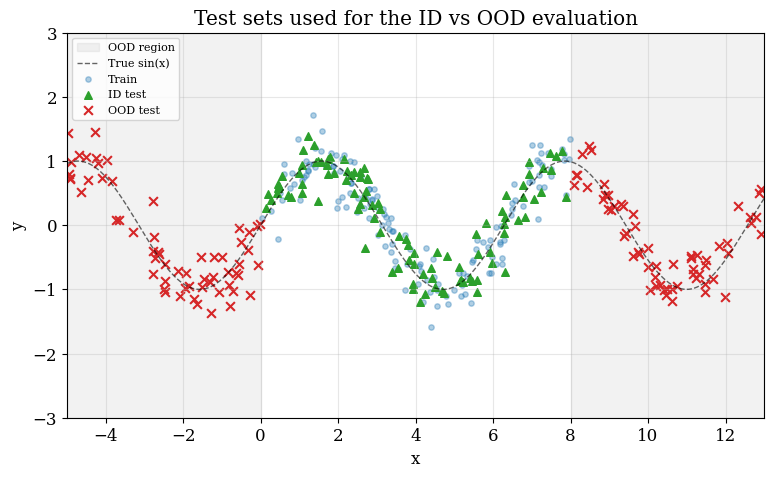

In [30]:
# What is given to test OOD: train data + held-out ID test + OOD test points
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD region")
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=15, alpha=0.35, label="Train")
ax.scatter(X_test_id.flatten().numpy(), y_test_id_np, c="tab:green", marker="^", s=30, label="ID test")
ax.scatter(X_test_ood.flatten().numpy(), y_test_ood_np, c="tab:red", marker="x", s=40, label="OOD test")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Test sets used for the ID vs OOD evaluation")
ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_ood_testsets.png"), dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# ID vs OOD scored metrics per variant (held-out test sets with targets)
ood_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    net = variant_results[vname]["model"]
    mu_id,  epi_id  = bnn_predict(net, X_test_id)
    mu_ood, epi_ood = bnn_predict(net, X_test_ood)
    m_id  = regression_metrics(y_test_id_np,  mu_id,  np.sqrt(epi_id  ** 2 + sigma_noise ** 2))
    m_ood = regression_metrics(y_test_ood_np, mu_ood, np.sqrt(epi_ood ** 2 + sigma_noise ** 2))
    ood_rows.append({
        "ID NLL": m_id["NLL"],                 "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"],               "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic": float(epi_id.mean()),  "OOD Epistemic": float(epi_ood.mean()),
        "Epistemic Ratio (OOD/ID)": float(epi_ood.mean() / epi_id.mean()) if epi_id.mean() > 0 else float("inf"),
    })
ood_df = pd.DataFrame(ood_rows, index=[s["plot_title"] for s in variant_specs])
ood_df.index.name = "Variant"
print("ID vs OOD: NLL/RMSE should be HIGHER and Coverage_95 should DROP on OOD; epistemic ratio > 1")
display(ood_df.round(4))

os.makedirs("results/metrics", exist_ok=True)
ood_df.to_csv("results/metrics/sinusoid_bayesian_ood_metrics.csv")
print("\nSaved OOD metrics to results/metrics/sinusoid_bayesian_ood_metrics.csv")

ID vs OOD: NLL/RMSE should be HIGHER and Coverage_95 should DROP on OOD; epistemic ratio > 1


,ID NLL,OOD NLL,ID RMSE,OOD RMSE,ID Coverage_95,OOD Coverage_95,ID Epistemic,OOD Epistemic,Epistemic Ratio (OOD/ID)
Variant,,,,,,,,,
Flipout / scratch,0.6965,9.0429,0.4540,1.6433,0.93,0.2000,0.1917,0.2291,1.1949
Flipout / moped,1.5323,1.7136,0.5244,1.2784,1.00,0.9917,1.7729,1.5730,0.8873
BBB / scratch,1.2558,7.7392,0.5901,1.3094,0.70,0.3667,0.1673,0.1785,1.0671
BBB / moped,1.6206,1.7415,0.6163,1.3646,1.00,1.0000,1.9273,1.5728,0.8161



Saved OOD metrics to results/metrics/sinusoid_bayesian_ood_metrics.csv


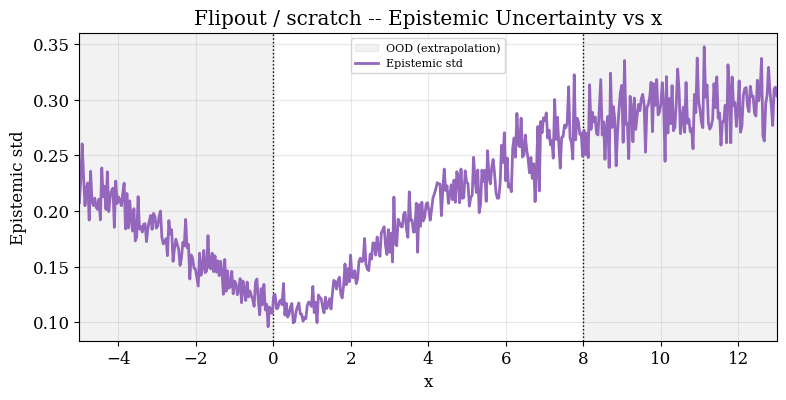

  Saved OOD epistemic figure for: flipout_scratch


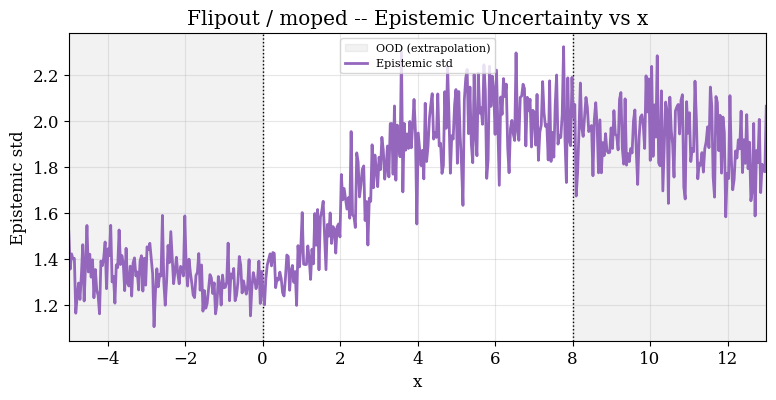

  Saved OOD epistemic figure for: flipout_moped


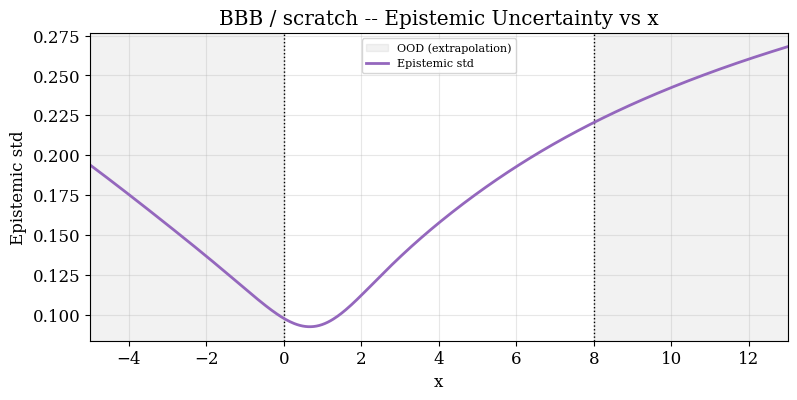

  Saved OOD epistemic figure for: bbb_scratch


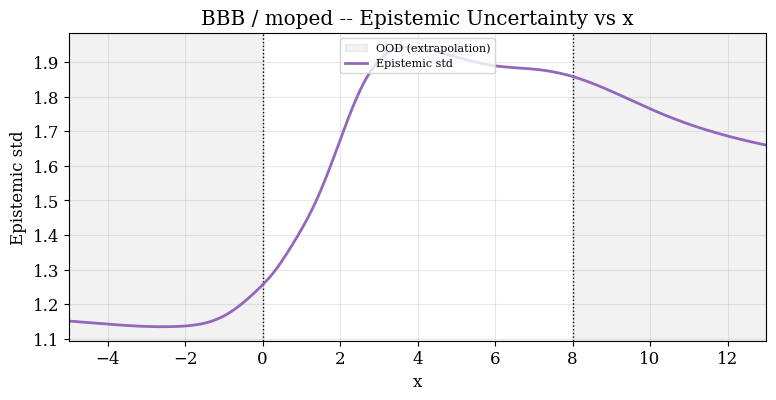

  Saved OOD epistemic figure for: bbb_moped

Done: 4 OOD epistemic figures written to ../figures


In [32]:
# Per-variant OOD visualization: epistemic std across x (ID region clear, OOD shaded)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    epi = variant_results[vname]["epi_std"]
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, epi, color="tab:purple", lw=2, label="Epistemic std")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} -- Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_ood_epistemic.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved OOD epistemic figure for: {vname}")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures written to {FIGURES_DIR}")

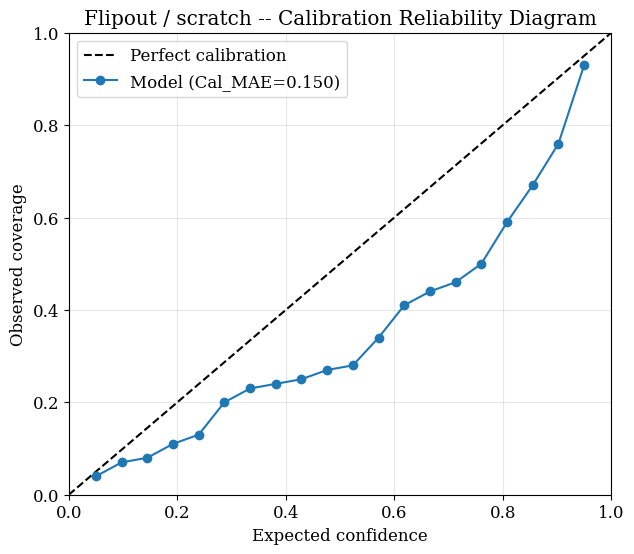

  Saved calibration figure for: flipout_scratch


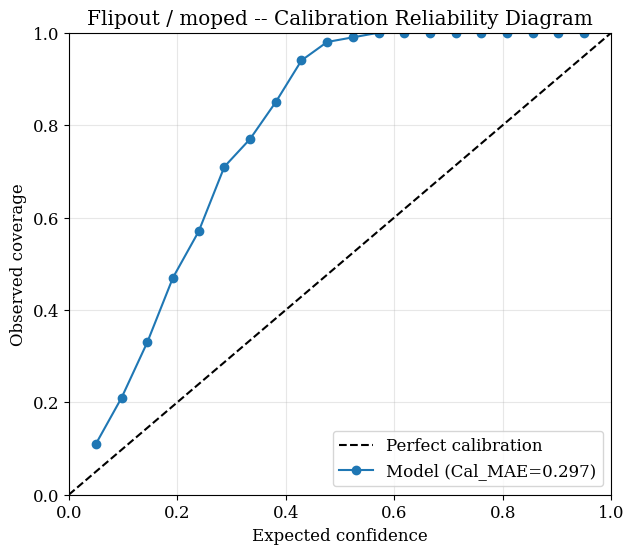

  Saved calibration figure for: flipout_moped


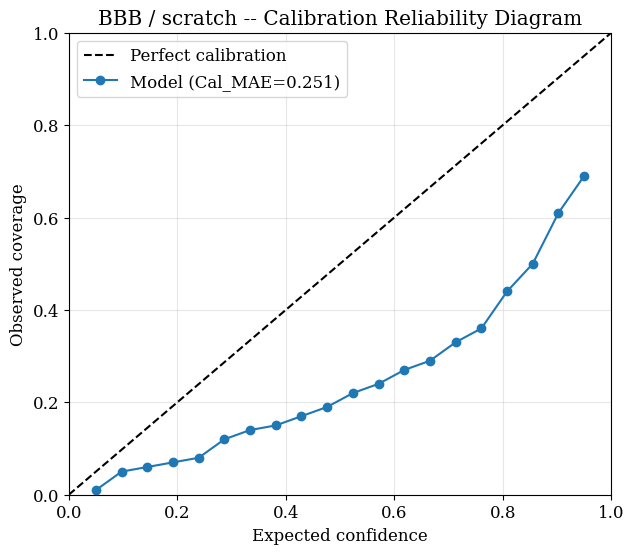

  Saved calibration figure for: bbb_scratch


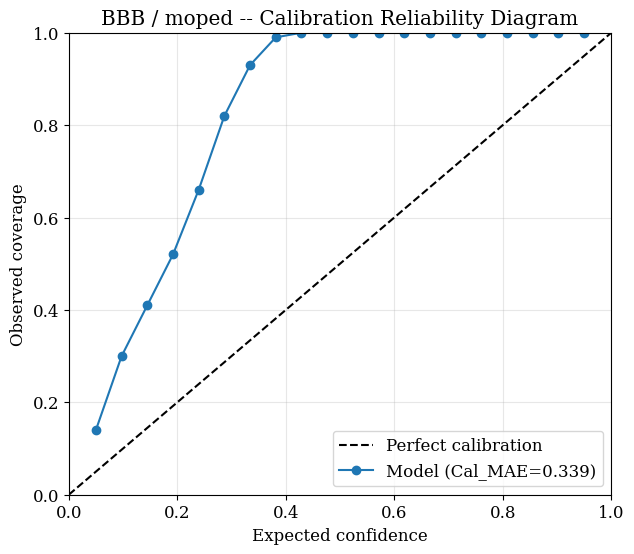

  Saved calibration figure for: bbb_moped

Done: 4 calibration figures written to ../figures


In [33]:
# Per-variant calibration reliability diagrams (ID test set)
from scipy.stats import norm as _norm

conf_levels = np.linspace(0.05, 0.95, 20)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    net = variant_results[vname]["model"]
    mu_id, epi_id = bnn_predict(net, X_test_id)
    total_id = np.sqrt(epi_id ** 2 + sigma_noise ** 2)
    resid = y_test_id_np - mu_id
    z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
    observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
    cal_mae = float(np.mean(np.abs(observed - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, observed, "o-", label=f"Model (Cal_MAE={cal_mae:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} -- Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_calibration.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved calibration figure for: {vname}")
print(f"\nDone: {len(variant_specs)} calibration figures written to {FIGURES_DIR}")
